# Projeto Avaliativo – Análise de Dados com Python

## Fase 3 – Camada Gold: Análise de Dados

## Introdução



Este notebook apresenta a etapa de análise de dados (Camada Gold) do pipeline desenvolvido para o conjunto de dados Viagens a Serviço, disponibilizado pelo Portal da Transparência do Governo Federal.

Após a extração dos dados e sua transformação nas camadas Raw e Silver, são realizadas consultas analíticas para responder às perguntas de negócio propostas no projeto. As análises utilizam consultas SQL, tabelas e gráficos para transformar os dados tratados em informações que apoiam a compreensão dos gastos com viagens a serviço.

Além disso, é criada uma camada Gold com dados agregados, utilizando operações de JOIN e GROUP BY, permitindo a geração de indicadores voltados à tomada de decisão.

## Configuração do Ambiente

Nesta etapa são importadas as bibliotecas utilizadas nas análises e estabelecida a conexão com o banco de dados criado nas etapas anteriores do pipeline.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# import banco
import scripts.banco as banco

In [5]:
conexao = banco.conectar()

def consultar(sql):
    """Executa uma consulta SQL e retorna um DataFrame."""
    return pd.read_sql(sql, conexao)


def reais(valor):
    """Formata valores numéricos como moeda brasileira."""
    texto = f'{valor:,.2f}'
    return 'R$ ' + texto.replace(',', 'X').replace('.', ',').replace('X', '.')


print('Conectado ao MySQL com sucesso.')

Conectado ao MySQL com sucesso.


## Visão Geral da Base de Dados

Antes de responder às perguntas de negócio, são apresentados alguns indicadores gerais da base utilizada nas análises, como a quantidade de registros e o período coberto pelos dados. Essas informações auxiliam na contextualização dos resultados apresentados nas seções seguintes.

### Quantidade de registros

In [6]:
consulta_registros = """
SELECT 'silver_viagem' AS tabela, COUNT(*) AS total_registros
FROM silver_viagem

UNION ALL

SELECT 'silver_pagamento', COUNT(*)
FROM silver_pagamento

UNION ALL

SELECT 'silver_passagem', COUNT(*)
FROM silver_passagem

UNION ALL

SELECT 'silver_trecho', COUNT(*)
FROM silver_trecho;
"""

df_registros = pd.read_sql(consulta_registros, conexao)

display(df_registros)

C:\Users\Win10\AppData\Local\Temp\ipykernel_2748\1518984659.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_registros = pd.read_sql(consulta_registros, conexao)


,tabela,total_registros
0,silver_viagem,341860
1,silver_pagamento,606916
2,silver_passagem,167260
3,silver_trecho,763349


### Análise dos resultados

A camada Silver é composta por 341.860 viagens, 606.916 pagamentos, 167.260 passagens e 763.349 trechos. Esses volumes demonstram que a base possui dados suficientes para responder às perguntas de negócio propostas, servindo como fonte para a construção da camada Gold.

### Período dos dados

Nesta etapa é identificado o período coberto pelos registros de viagens presentes na base de dados. Essa informação permite contextualizar temporalmente as análises realizadas nas seções seguintes.

In [18]:
consulta_periodo = """
SELECT
    MIN(data_inicio) AS primeira_data,
    MAX(data_fim) AS ultima_data
FROM silver_viagem;
"""

df_periodo = pd.read_sql(consulta_periodo, conexao)

display(df_periodo)

C:\Users\Win10\AppData\Local\Temp\ipykernel_16628\2997248221.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_periodo = pd.read_sql(consulta_periodo, conexao)


,primeira_data,ultima_data
0,2025-01-01,2026-04-05


### Análise do período

A base analisada contempla registros de viagens com início em janeiro de 2025 e término registrado até abril de 2026. Essa abrangência temporal representa o intervalo utilizado para as análises de gastos e comportamento das viagens.

## Pergunta 1 – Quais são os 5 órgãos com maior custo total?

Para identificar os órgãos com maior impacto financeiro, foi realizada uma agregação dos valores totais das viagens por órgão superior. A análise considera a soma do campo valor_total da camada Silver, permitindo identificar quais órgãos concentraram os maiores gastos no período analisado.

In [20]:
sql_q1 = '''
SELECT
    nome_orgao_superior AS orgao,
    SUM(valor_total) AS custo_total
FROM silver_viagem
GROUP BY nome_orgao_superior
ORDER BY custo_total DESC
LIMIT 5;
'''

q1 = consultar(sql_q1)

q1['custo_total_formatado'] = q1['custo_total'].apply(reais)

q1

C:\Users\Win10\AppData\Local\Temp\ipykernel_16628\898623408.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,orgao,custo_total,custo_total_formatado
0,Ministério da Justiça e Segurança Pública,4.869331e+08,"R$ 486.933.121,65"
1,Ministério da Defesa,1.560703e+08,"R$ 156.070.304,49"
2,Ministério da Educação,1.112913e+08,"R$ 111.291.349,34"
3,Ministério do Meio Ambiente e Mudança do Clima,4.969771e+07,"R$ 49.697.710,16"
4,Ministério da Previdência Social,4.041731e+07,"R$ 40.417.309,06"


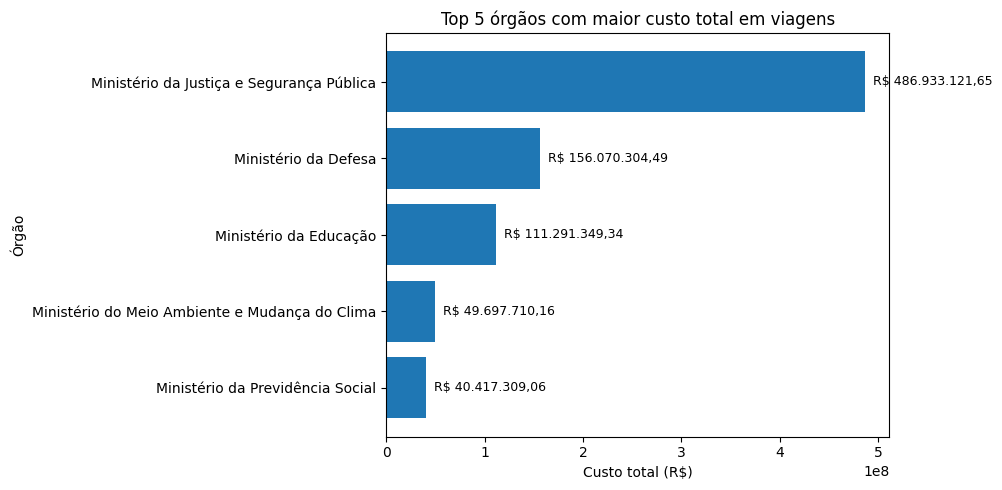

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(
    q1['orgao'],
    q1['custo_total']
)

ax.invert_yaxis()

ax.set_title('Top 5 órgãos com maior custo total em viagens')
ax.set_xlabel('Custo total (R$)')
ax.set_ylabel('Órgão')

for i, valor in enumerate(q1['custo_total']):
    ax.text(
        valor,
        i,
        '  ' + reais(valor),
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

### Análise dos resultados

A análise identificou os cinco órgãos superiores com maior custo total em viagens no período avaliado.

O Ministério da Justiça e Segurança Pública apresentou o maior volume de gastos, seguido pelo Ministério da Defesa e pelo Ministério da Educação. A concentração dos valores nesses órgãos indica uma maior demanda por deslocamentos relacionados
às suas atividades institucionais.

Essa análise permite identificar quais órgãos possuem maior participação nos gastos com viagens e pode auxiliar em avaliações futuras relacionadas à quantidade de viagens realizadas, duração dos deslocamentos e tipos de pagamento utilizados.

## Pergunta 2 – Quais são os 3 destinos com maior custo médio por viagem?

Para responder esta pergunta, foram utilizados os dados da tabela silver_trecho, relacionados com a tabela silver_viagem através do identificador da viagem.

A análise considera o custo médio das viagens por destino. Para evitar que destinos com poucas ocorrências influenciassem o resultado, foram considerados apenas destinos com no mínimo 50 viagens registradas no período analisado.

In [18]:
sql_q2 = '''
SELECT
    destino,
    AVG(custo_viagem) AS custo_medio,
    COUNT(*) AS quantidade_viagens
FROM (
    SELECT DISTINCT
        CONCAT(t.destino_cidade, '/', t.destino_uf) AS destino,
        v.id_viagem,
        v.valor_total AS custo_viagem
    FROM silver_trecho t
    INNER JOIN silver_viagem v
        ON t.id_viagem = v.id_viagem
    WHERE t.destino_cidade IS NOT NULL
) AS destinos_viagens
GROUP BY destino
HAVING COUNT(*) >= 50
ORDER BY custo_medio DESC
LIMIT 3;
'''

q2 = consultar(sql_q2)

q2['custo_medio_formatado'] = q2['custo_medio'].apply(reais)

q2

C:\Users\Win10\AppData\Local\Temp\ipykernel_2748\898623408.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,destino,custo_medio,quantidade_viagens,custo_medio_formatado
0,Monte Negro/Rondônia,84926.029286,98,"R$ 84.926,03"
1,Sananduva/Rio Grande do Sul,78792.232233,103,"R$ 78.792,23"
2,Nonoai/Rio Grande do Sul,77931.916752,117,"R$ 77.931,92"


In [20]:
consultar("""
SELECT DISTINCT
    t.id_viagem,
    CONCAT(t.destino_cidade, '/', t.destino_uf) AS destino
FROM silver_trecho t
WHERE t.destino_cidade = 'Monte Negro'
  AND t.destino_uf = 'Rondônia'
LIMIT 20;
""")

C:\Users\Win10\AppData\Local\Temp\ipykernel_2748\898623408.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,id_viagem,destino
0,0000000000020638998,Monte Negro/Rondônia
1,0000000000020639012,Monte Negro/Rondônia
2,0000000000020639017,Monte Negro/Rondônia
3,0000000000020639095,Monte Negro/Rondônia
4,0000000000020639150,Monte Negro/Rondônia
5,0000000000020639151,Monte Negro/Rondônia
6,0000000000020639158,Monte Negro/Rondônia
7,0000000000020648872,Monte Negro/Rondônia
8,0000000000020648887,Monte Negro/Rondônia
9,0000000000020648890,Monte Negro/Rondônia


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(
    q2['destino'],
    q2['custo_medio']
)

ax.invert_yaxis()

ax.set_title('Top 3 destinos com maior custo médio por viagem')
ax.set_xlabel('Custo médio por viagem (R$)')
ax.set_ylabel('Destino')

for i, valor in enumerate(q2['custo_medio']):
    ax.text(
        valor,
        i,
        '  ' + reais(valor),
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

### Análise dos resultados

A análise identificou os três destinos com maior custo médio por viagem no período avaliado. Para evitar distorções causadas por destinos com poucas ocorrências, foram considerados apenas destinos com no mínimo 50 viagens registradas.

Os resultados mostram que Monte Negro/Rondônia apresentou o maior custo médio por viagem, seguido por Sananduva/Rio Grande do Sul e Nonoai/Rio Grande do Sul.

Esses indicadores permitem identificar destinos que apresentam maior impacto financeiro médio, auxiliando no acompanhamento dos gastos relacionados às viagens a
serviço.

## Pergunta 3 – Qual foi a viagem de maior duração e seu custo total?

Para identificar a viagem com maior duração, foi utilizada a coluna calculada `duracao_dias` da camada Silver, ordenando os registros de forma decrescente.

Para evitar que registros sem impacto financeiro influenciassem a análise, foram consideradas apenas viagens com valor_total superior a zero.

O resultado apresenta a viagem de maior duração e seu respectivo custo total.

In [41]:
sql_media_duracao = '''
SELECT
    AVG(duracao_dias) AS media_dias
FROM silver_viagem
WHERE valor_total > 0;
'''

media_duracao = consultar(sql_media_duracao)

media_dias = media_duracao['media_dias'][0]

media_dias

C:\Users\Win10\AppData\Local\Temp\ipykernel_16628\898623408.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


np.float64(7.1618)

In [42]:
dados_grafico_q3 = pd.DataFrame({
    'categoria': [
        'Duração média\n(todas as viagens)',
        'Viagem mais longa\n(' + q3['id_viagem'][0] + ')'
    ],
    'dias': [
        media_dias,
        q3['duracao_dias'][0]
    ]
})

dados_grafico_q3

,categoria,dias
0,Duração média\n(todas as viagens),7.1618
1,Viagem mais longa\n(0000000000020793594),378.0000


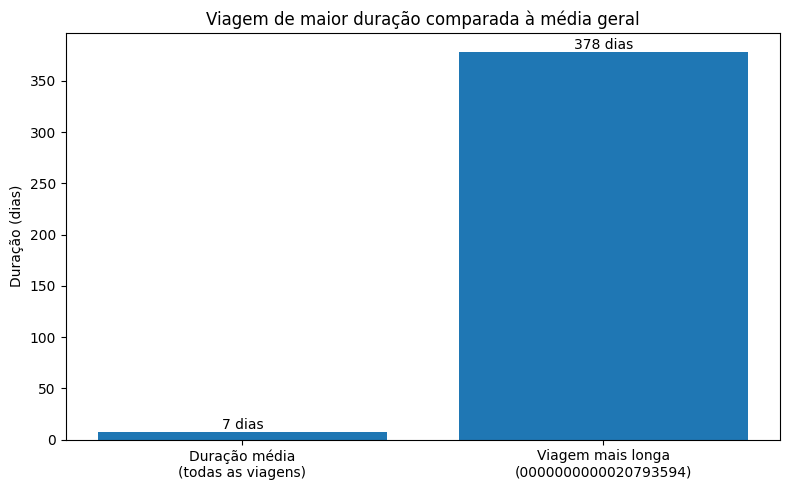

In [40]:
fig, ax = plt.subplots(figsize=(8,5))

ax.bar(
    dados_grafico_q3['categoria'],
    dados_grafico_q3['dias']
)

ax.set_title('Viagem de maior duração comparada à média geral')
ax.set_ylabel('Duração (dias)')

for i, valor in enumerate(dados_grafico_q3['dias']):
    ax.text(
        i,
        valor,
        f'{valor:.0f} dias',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

### Análise dos resultados

A viagem de maior duração registrada apresentou 378 dias, enquanto a duração média das viagens com valor informado foi de aproximadamente 7 dias. O registro com maior duração não possui custo total associado na base analisada, diferenciando-se dos demais casos considerados. Essa ocorrência deve ser observada em análises futuras, pois pode impactar interpretações relacionadas à relação entre duração e custo das viagens.

## Camada Gold

Após responder às três primeiras perguntas de negócio utilizando os dados da camada Silver, nesta etapa é criada uma camada Gold agregada. Essa camada consolida informações por meio de operações de JOIN e GROUP BY, permitindo a geração de indicadores voltados à análise dos gastos com viagens a serviço.

Conforme os requisitos do projeto, a camada Gold será criada no banco de dados tanto como uma tabela quanto como uma VIEW, servindo de base para as próximas análises.

### Criação da tabela Gold

A primeira etapa consiste na criação de uma tabela agregada na camada Gold. Para isso, são utilizadas as tabelas `silver_viagem` e `silver_pagamento`, relacionadas pelo identificador da viagem (`id_viagem`).

A agregação é realizada por órgão superior e tipo de pagamento, utilizando operações de JOIN e GROUP BY. Essa estrutura consolida informações sobre a quantidade de pagamentos, o valor total pago e o valor médio por tipo de pagamento, servindo de base para as análises de negócio apresentadas nas próximas seções.

In [5]:
banco.executar(conexao, "DROP TABLE IF EXISTS gold_resumo_orgao")

banco.executar(conexao, """
CREATE TABLE gold_resumo_orgao AS
SELECT
    v.nome_orgao_superior AS orgao,
    COUNT(DISTINCT v.id_viagem) AS total_viagens,
    COUNT(p.id_pagamento) AS total_pagamentos,
    SUM(p.valor) AS valor_total_pago,
    AVG(p.valor) AS valor_medio_pagamento
FROM silver_viagem AS v
INNER JOIN silver_pagamento AS p
    ON v.id_viagem = p.id_viagem
GROUP BY
    v.nome_orgao_superior;
""")

print("Tabela gold_resumo_orgao criada com sucesso.")

Tabela gold_resumo_orgao criada com sucesso.


### Validação da tabela Gold

Após a criação da tabela `gold_resumo_orgao`, foi realizada uma consulta para verificar os dados agregados.

Os resultados demonstram que a tabela consolidou corretamente as informações por órgão superior, apresentando a quantidade de viagens, o total de pagamentos, o valor total pago e o valor médio dos pagamentos. Essa estrutura servirá como base para as próximas análises da camada Gold.

In [6]:
gold = consultar("""
SELECT *
FROM gold_resumo_orgao
ORDER BY valor_total_pago DESC
LIMIT 10;
""")

gold

C:\Users\Win10\AppData\Local\Temp\ipykernel_11748\898623408.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,orgao,total_viagens,total_pagamentos,valor_total_pago,valor_medio_pagamento
0,Ministério da Justiça e Segurança Pública,75633,175814,4.888311e+08,2780.387857
1,Ministério da Defesa,61388,93574,1.565498e+08,1673.004979
2,Ministério da Educação,60011,93340,1.118974e+08,1198.815453
3,Ministério do Meio Ambiente e Mudança do Clima,13397,26394,5.012304e+07,1899.031742
4,Ministério da Previdência Social,7911,20106,4.065949e+07,2022.256771
5,Ministério da Saúde,8185,18914,3.951792e+07,2089.347469
6,Ministério da Fazenda,11760,23613,3.266602e+07,1383.391243
7,Ministério dos Povos Indígenas,5046,10618,2.644114e+07,2490.218704
8,Ministério das Relações Exteriores,1944,3757,2.572434e+07,6847.042097
9,Ministério do Desenvolvimento Agrário e Agricu...,7782,13247,2.217168e+07,1673.713556


### Criação da VIEW Gold

Além da tabela agregada, é criada uma VIEW contendo a mesma estrutura da camada Gold. A VIEW permite consultar os dados consolidados de forma dinâmica, refletindo automaticamente possíveis atualizações realizadas nas tabelas da camada Silver.

In [8]:
banco.executar(conexao, "DROP VIEW IF EXISTS vw_gold_resumo_orgao")

banco.executar(conexao, """
CREATE VIEW vw_gold_resumo_orgao AS
SELECT
    orgao,
    total_viagens,
    total_pagamentos,
    valor_total_pago,
    valor_medio_pagamento
FROM gold_resumo_orgao;
""")

print("VIEW criada com sucesso.")

VIEW criada com sucesso.


In [9]:
gold_view = consultar("""
SELECT *
FROM vw_gold_resumo_orgao
ORDER BY valor_total_pago DESC
LIMIT 10;
""")

gold_view

C:\Users\Win10\AppData\Local\Temp\ipykernel_11748\898623408.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,orgao,total_viagens,total_pagamentos,valor_total_pago,valor_medio_pagamento
0,Ministério da Justiça e Segurança Pública,75633,175814,4.888311e+08,2780.387857
1,Ministério da Defesa,61388,93574,1.565498e+08,1673.004979
2,Ministério da Educação,60011,93340,1.118974e+08,1198.815453
3,Ministério do Meio Ambiente e Mudança do Clima,13397,26394,5.012304e+07,1899.031742
4,Ministério da Previdência Social,7911,20106,4.065949e+07,2022.256771
5,Ministério da Saúde,8185,18914,3.951792e+07,2089.347469
6,Ministério da Fazenda,11760,23613,3.266602e+07,1383.391243
7,Ministério dos Povos Indígenas,5046,10618,2.644114e+07,2490.218704
8,Ministério das Relações Exteriores,1944,3757,2.572434e+07,6847.042097
9,Ministério do Desenvolvimento Agrário e Agricu...,7782,13247,2.217168e+07,1673.713556


### Análise dos resultados

A consulta realizada na VIEW confirmou que os dados correspondem aos registros da tabela `gold_resumo_orgao`, validando sua criação.

A VIEW disponibiliza as informações agregadas de forma dinâmica, permitindo sua utilização nas análises da camada Gold sem a necessidade de recriar a lógica de agregação.

## Análises utilizando a camada Gold

Após a criação e validação da camada Gold, as próximas análises utilizam a VIEW `vw_gold_resumo_orgao`, que reúne informações agregadas por órgão. Essa abordagem simplifica as consultas e demonstra a utilização da camada Gold como fonte para responder às perguntas de negócio.

## Pergunta 4 – Qual o tipo de pagamento com maior valor médio?

Para identificar o tipo de pagamento com maior valor médio, foi utilizada a tabela `silver_pagamento`, que contém os registros dos pagamentos vinculados às viagens realizadas.

A análise foi realizada agrupando os registros pelo campo `tipo_pagamento` e calculando o valor médio dos pagamentos. Em seguida, os resultados foram ordenados de forma decrescente para identificar os tipos de pagamento com maior valor médio registrado.

Essa análise permite compreender quais modalidades de pagamento apresentam maior impacto financeiro médio dentro da base de viagens a serviço.

In [14]:
sql_q4 = '''
SELECT
    tipo_pagamento,
    AVG(valor) AS valor_medio
FROM silver_pagamento
GROUP BY tipo_pagamento
ORDER BY valor_medio DESC;
'''

q4 = consultar(sql_q4)
q4['valor_medio_formatado'] = q4['valor_medio'].apply(reais)

q4

C:\Users\Win10\AppData\Local\Temp\ipykernel_11748\898623408.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,tipo_pagamento,valor_medio,valor_medio_formatado
0,DIÁRIAS,2078.280299,"R$ 2.078,28"
1,PASSAGEM,1878.344393,"R$ 1.878,34"
2,Serviço correlato: seguro,447.514653,"R$ 447,51"
3,RESTITUIÇÃO,245.702610,"R$ 245,70"


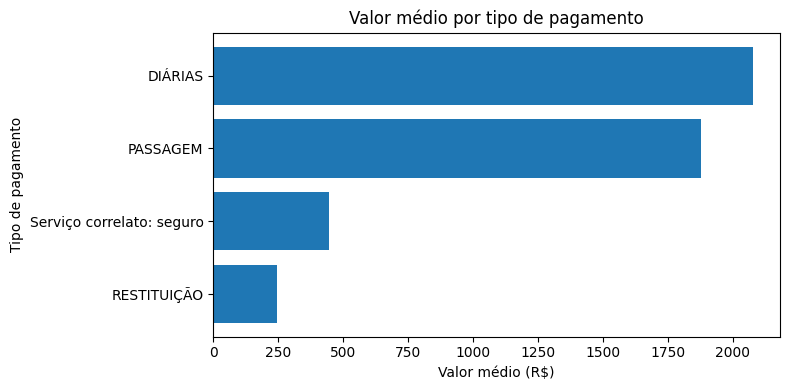

In [15]:
plt.figure(figsize=(8, 4))

plt.barh(q4['tipo_pagamento'], q4['valor_medio'])

plt.title('Valor médio por tipo de pagamento')
plt.xlabel('Valor médio (R$)')
plt.ylabel('Tipo de pagamento')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## Análise dos resultados

A análise dos valores médios por tipo de pagamento identificou que **DIÁRIAS** apresentou o maior valor médio registrado, com aproximadamente **R$ 2.078,28** por pagamento.

O tipo de pagamento **PASSAGEM** apresentou o segundo maior valor médio, com aproximadamente **R$ 1.878,34**, enquanto as categorias **Serviço correlato: seguro** e **RESTITUIÇÃO** apresentaram valores médios inferiores.

Os resultados indicam que as despesas relacionadas às diárias possuem maior impacto financeiro médio entre os tipos de pagamento analisados, sendo um dos principais componentes dos gastos associados às viagens a serviço.

## Pergunta 5 – Qual o meio de transporte mais usado nos trechos?

Para identificar o meio de transporte mais utilizado nos trechos das viagens, foi analisada a tabela `silver_trecho`, que contém os registros dos deslocamentos realizados.

A análise foi realizada contabilizando a quantidade de ocorrências para cada meio de transporte, permitindo identificar quais modalidades apresentam maior frequência nos trajetos registrados.

Essa informação auxilia na compreensão do perfil de deslocamento das viagens a serviço e na identificação dos meios de transporte mais utilizados na base analisada.

In [16]:
sql_q5 = '''
SELECT
    meio_transporte,
    COUNT(*) AS quantidade_trechos
FROM silver_trecho
GROUP BY meio_transporte
ORDER BY quantidade_trechos DESC;
'''

q5 = consultar(sql_q5)

q5

C:\Users\Win10\AppData\Local\Temp\ipykernel_11748\898623408.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,meio_transporte,quantidade_trechos
0,Veículo Oficial,386424
1,Aéreo,232666
2,Rodoviário,64970
3,Veículo Próprio,42846
4,Inválido,26659
5,Fluvial,8429
6,Ferroviário,874
7,Marítimo,481


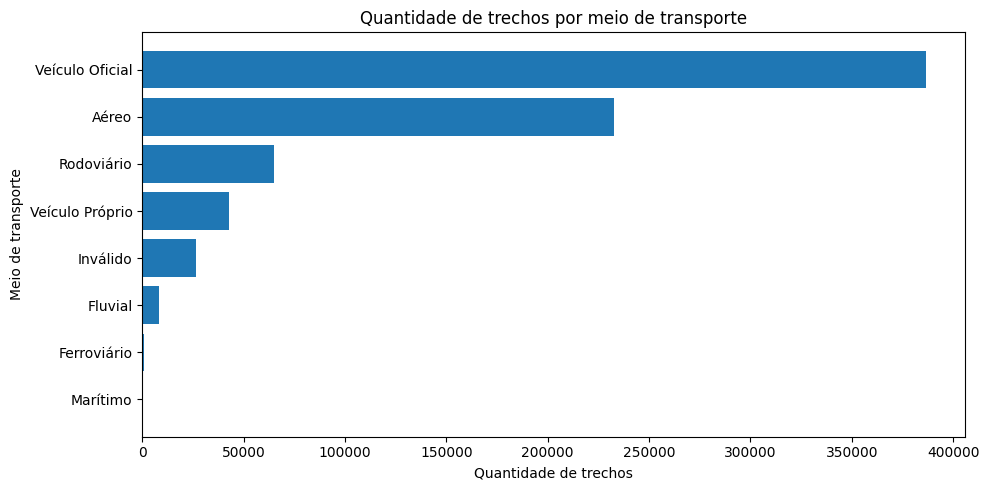

In [17]:
plt.figure(figsize=(10, 5))

plt.barh(q5['meio_transporte'], q5['quantidade_trechos'])

plt.title('Quantidade de trechos por meio de transporte')
plt.xlabel('Quantidade de trechos')
plt.ylabel('Meio de transporte')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## Análise dos resultados

A análise dos trechos registrados identificou que o meio de transporte mais utilizado foi o **Veículo Oficial**, com **386.424 ocorrências**, seguido pelo transporte **Aéreo**, com **232.666 registros**.

Os demais meios de transporte apresentaram uma frequência menor, como o transporte **Rodoviário** e o uso de **Veículo Próprio**. Também foram identificados registros classificados como **Inválido**, que representam ocorrências sem uma categorização válida do meio de transporte.

Os resultados demonstram que os deslocamentos realizados com veículo oficial e transporte aéreo concentram a maior parte dos trechos analisados, indicando os principais padrões de mobilidade das viagens a serviço.

## Pergunta 6 – Qual UF de destino aparece em mais trechos?

Para identificar quais unidades federativas aparecem com maior frequência como destino das viagens, foi realizada uma análise dos registros da tabela `silver_trecho`.

A consulta contabilizou a quantidade de trechos agrupados por UF de destino, permitindo identificar os estados com maior ocorrência nos deslocamentos registrados.

Essa análise possibilita compreender a distribuição geográfica dos destinos das viagens a serviço e identificar as regiões com maior concentração de deslocamentos.

In [18]:
sql_q6 = '''
SELECT
    destino_uf,
    COUNT(*) AS quantidade_trechos
FROM silver_trecho
GROUP BY destino_uf
ORDER BY quantidade_trechos DESC;
'''

q6 = consultar(sql_q6)

q6

C:\Users\Win10\AppData\Local\Temp\ipykernel_11748\898623408.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,destino_uf,quantidade_trechos
0,São Paulo,82722
1,Distrito Federal,79962
2,Minas Gerais,50965
3,Rio de Janeiro,44197
4,Paraná,42603
5,Pará,40044
6,Rio Grande do Sul,38684
7,Mato Grosso do Sul,30516
8,Bahia,28375
9,Pernambuco,28372


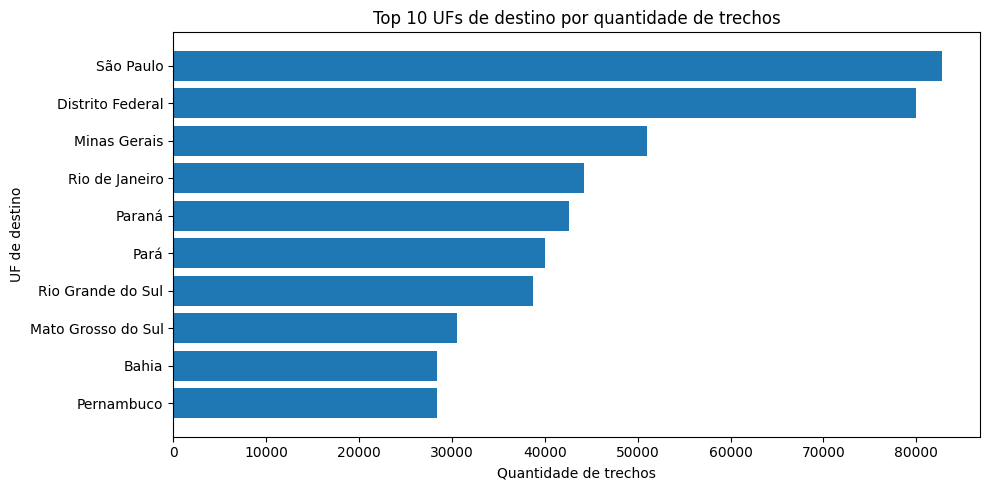

In [19]:
q6_top10 = q6[q6['destino_uf'].notna()].head(10)

plt.figure(figsize=(10, 5))

plt.barh(q6_top10['destino_uf'], q6_top10['quantidade_trechos'])

plt.title('Top 10 UFs de destino por quantidade de trechos')
plt.xlabel('Quantidade de trechos')
plt.ylabel('UF de destino')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## Análise dos resultados

A análise dos trechos por unidade federativa de destino identificou que **São Paulo** foi o destino com maior quantidade de ocorrências, totalizando **82.722 trechos registrados**.

Em seguida, aparecem o **Distrito Federal**, com **79.962 trechos**, e **Minas Gerais**, com **50.965 registros**, demonstrando uma maior concentração dos deslocamentos para essas regiões.

Também foram encontrados registros sem UF de destino preenchida e ocorrências classificadas como inválidas. Esses registros não foram considerados na interpretação dos resultados, pois não representam uma unidade federativa válida.

Os dados indicam que os deslocamentos das viagens a serviço apresentam maior concentração nos principais centros administrativos e econômicos do país, com destaque para São Paulo e Distrito Federal.

## Pergunta 7 – Qual órgão pagou mais no total?

Para identificar o órgão responsável pelo maior volume de pagamentos, foi realizada uma análise dos registros financeiros da camada Silver.

A consulta agrupou os valores pagos por órgão pagador, utilizando a soma dos valores registrados para cada instituição. Essa análise permite identificar quais órgãos concentram os maiores gastos relacionados às viagens a serviço.

O resultado possibilita uma visão consolidada da distribuição dos recursos financeiros entre os órgãos envolvidos.

In [21]:
sql_q7 = '''
SELECT
    nome_orgao_pagador,
    SUM(valor) AS valor_total_pago
FROM silver_pagamento
GROUP BY nome_orgao_pagador
ORDER BY valor_total_pago DESC
LIMIT 10;
'''

q7 = consultar(sql_q7)
q7['valor_total_pago_formatado'] = q7['valor_total_pago'].apply(reais)

q7

C:\Users\Win10\AppData\Local\Temp\ipykernel_11748\898623408.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,nome_orgao_pagador,valor_total_pago,valor_total_pago_formatado
0,Fundo Nacional de Segurança Pública,2.784810e+08,"R$ 278.481.047,89"
1,Sigiloso,2.004848e+08,"R$ 200.484.801,68"
2,Comando da Aeronáutica,8.176914e+07,"R$ 81.769.144,77"
3,Instituto Nacional do Seguro Social,3.742760e+07,"R$ 37.427.601,45"
4,Comando do Exército,3.687264e+07,"R$ 36.872.643,95"
5,Ministério da Gestão e da Inovação em Serviços...,3.554176e+07,"R$ 35.541.760,71"
6,Instituto Brasileiro do Meio Ambiente e dos Re...,3.158985e+07,"R$ 31.589.853,15"
7,Ministério das Relações Exteriores - Unidades ...,2.560538e+07,"R$ 25.605.376,38"
8,Receita Federal do Brasil,2.381103e+07,"R$ 23.811.027,00"
9,Ministério da Agricultura e Pecuária - Unidade...,2.289988e+07,"R$ 22.899.880,25"


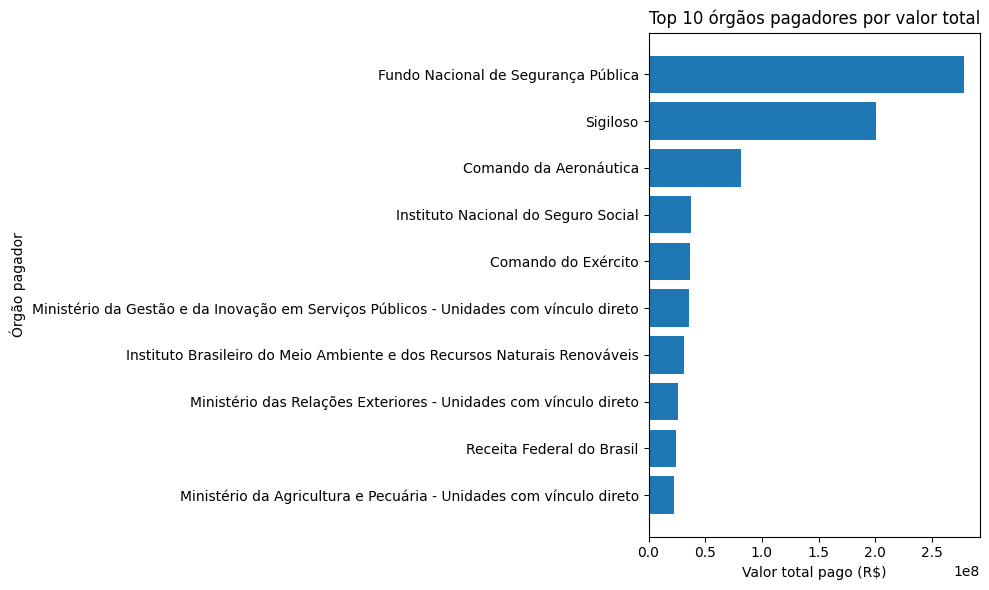

In [22]:
plt.figure(figsize=(10, 6))

plt.barh(q7['nome_orgao_pagador'], q7['valor_total_pago'])

plt.title('Top 10 órgãos pagadores por valor total')
plt.xlabel('Valor total pago (R$)')
plt.ylabel('Órgão pagador')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## Análise dos resultados

A análise dos valores pagos por órgão identificou que o **Fundo Nacional de Segurança Pública** apresentou o maior valor total registrado, com aproximadamente **R$ 278,48 milhões** em pagamentos relacionados às viagens a serviço.

Em seguida, aparece o órgão classificado como **Sigiloso**, com aproximadamente **R$ 200,48 milhões**, seguido pelo **Comando da Aeronáutica**, com aproximadamente **R$ 81,77 milhões**.

Os demais órgãos apresentaram valores inferiores em comparação aos líderes do ranking, demonstrando uma concentração significativa dos pagamentos em algumas instituições específicas.

Essa análise permite visualizar quais órgãos possuem maior participação nos gastos com viagens a serviço, contribuindo para o acompanhamento e a transparência da utilização dos recursos públicos.